In [3]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import List
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)

def load_all_csvs(csv_paths: List[str]) -> pd.DataFrame:
        """Load and combine multiple experiment CSVs. Do simple data processing for later convenience"""
        dfs = []
        for path in csv_paths:
            df = pd.read_csv(path, index_col=0)
            df['source_file'] = Path(path).parent.name  # track which experiment it came from
            dfs.append(df)
        
        combined = pd.concat(dfs, ignore_index=True)
        
        # add in diff representations of red params for convenience
        combined[['resizeTrigger', 'sizeLimit']] = combined['reduce_triggerSz_sizeLim'].str.strip('()').str.split(',', expand=True).astype(int)
        combined['gap_size_range_tuple'] = combined['gap_size_range'].apply(ast.literal_eval)
        combined['reduce_triggerSz_sizeLim_tuple'] = combined['reduce_triggerSz_sizeLim'].apply(ast.literal_eval)
        
        combined['time_norm'] = combined['sumtest_time_mean'] / combined['sumtest_time_mean'].max()
        combined['coverage_norm'] = combined['result_coverage_mean'] / combined['result_coverage_mean'].max()
        combined['efficiency'] = combined['coverage_norm'] / combined['time_norm']
        return combined

In [7]:
paths =   ['data/results/1090730076/ni_sweeping400/ni15_red500_250_sweep/results_sd1090730076.csv', 'data/results/1090730076/ni_sweeping400/ni15_red500_100_sweep/results_sd1090730076.csv', 'data/results/1090730076/ni_sweeping400/ni15_red500_10_sweep/results_sd1090730076.csv', 'data/results/1090730076/ni_sweeping400/ni15_red150_100_sweep/results_sd1090730076.csv', 'data/results/1090730076/ni_sweeping400/ni15_red150_10_sweep/results_sd1090730076.csv', 'data/results/1090730076/ni_sweeping400/ni15_red70_50_sweep/results_sd1090730076.csv', 'data/results/1090730076/ni_sweeping400/ni15_red70_10_sweep/results_sd1090730076.csv', 'data/results/1090730076/ni_sweeping400/ni15_red15_10_sweep/results_sd1090730076.csv', 'data/results/1090730076/ni_sweeping400/ni15_red10_5_sweep/results_sd1090730076.csv', 'data/results/1090730076/ni_sweeping400/ni15_red3_1_sweep/results_sd1090730076.csv']
df = load_all_csvs(paths)
df


,master_seed,data_type,num_trials,dataset_size,uncertain_ratio,interval_size_range,mult_size_range,num_intervals,start_interval_range,gap_size,interval_width,num_intervals_range,gap_size_range,interval_width_range,reduce_triggerSz_sizeLim,independent_variable,distribution,min_time_mean,min_time_std,max_time_mean,max_time_std,sum_time_mean,sum_time_std,sumtest_time_mean,sumtest_time_std,sum_results,reduce_calls_mean,max_interval_count_mean,total_interval_count_mean,combine_calls_mean,result_size_mean,minEffectiveIntervalCountMean,convergedToTotSize,result_coverage_mean,source_file,resizeTrigger,sizeLimit,gap_size_range_tuple,reduce_triggerSz_sizeLim_tuple,time_norm,coverage_norm,efficiency
0,1090730076,set,3,400,0.0,"(1, 100000)","(1, 5)",5,"(1, 1000)",NaN,NaN,NaN,"(0, 100)","(5, 6)","(500, 250)",gap_size_range,DistributionType.UNIFORM,1.294667,0.162920,0.663667,0.081961,12.469333,0.912322,13.333000,1.488761,"[NumericRange(185216, 1469393, '[)'), NumericR...",347.0,2450.0,307900.0,400.0,129.0,129.0,1710993.0,1710993.0,ni15_red500_250_sweep,500,250,"(0, 100)","(500, 250)",1.000000,0.147013,0.147013
1,1090730076,set,3,400,0.0,"(1, 100000)","(1, 5)",5,"(1, 1000)",NaN,NaN,NaN,"(0, 100)","(5, 6)","(500, 100)",gap_size_range,DistributionType.UNIFORM,1.165000,0.016872,0.603000,0.013736,9.131000,0.404874,8.657667,0.280835,"[NumericRange(185216, 4565234, '[)'), NumericR...",347.0,2450.0,230605.0,400.0,100.0,100.0,4679988.0,4679988.0,ni15_red500_100_sweep,500,100,"(0, 100)","(500, 100)",0.649341,0.402118,0.619270
2,1090730076,set,3,400,0.0,"(1, 100000)","(1, 5)",5,"(1, 1000)",NaN,NaN,NaN,"(0, 100)","(5, 6)","(500, 10)",gap_size_range,DistributionType.UNIFORM,1.017333,0.022485,0.581000,0.013638,7.874000,0.220241,7.745333,0.173352,"[NumericRange(185216, 470817, '[)')]",110.0,1875.0,115085.0,400.0,1.0,1.0,285601.0,285601.0,ni15_red500_10_sweep,500,10,"(0, 100)","(500, 10)",0.580915,0.024540,0.042243
3,1090730076,set,3,400,0.0,"(1, 100000)","(1, 5)",5,"(1, 1000)",NaN,NaN,NaN,"(0, 100)","(5, 6)","(150, 100)",gap_size_range,DistributionType.UNIFORM,1.142667,0.004922,0.600333,0.012658,6.003000,0.032135,6.044000,0.142901,"[NumericRange(185216, 1858341, '[)'), NumericR...",384.0,700.0,180570.0,400.0,100.0,100.0,1973095.0,1973095.0,ni15_red150_100_sweep,150,100,"(0, 100)","(150, 100)",0.453311,0.169534,0.373990
4,1090730076,set,3,400,0.0,"(1, 100000)","(1, 5)",5,"(1, 1000)",NaN,NaN,NaN,"(0, 100)","(5, 6)","(150, 10)",gap_size_range,DistributionType.UNIFORM,1.224667,0.044124,0.653333,0.052955,2.568000,0.091982,2.535333,0.051700,"[NumericRange(185216, 1403807, '[)'), NumericR...",198.0,625.0,60345.0,400.0,10.0,10.0,1237356.0,1237356.0,ni15_red150_10_sweep,150,10,"(0, 100)","(150, 10)",0.190155,0.106317,0.559108
5,1090730076,set,3,400,0.0,"(1, 100000)","(1, 5)",5,"(1, 1000)",NaN,NaN,NaN,"(0, 100)","(5, 6)","(70, 50)",gap_size_range,DistributionType.UNIFORM,0.568000,0.008287,0.567667,0.016938,1.722667,0.181889,1.397667,0.038143,"[NumericRange(185216, 198417, '[)')]",133.0,125.0,20620.0,400.0,1.0,1.0,13201.0,13201.0,ni15_red70_50_sweep,70,50,"(0, 100)","(70, 50)",0.104828,0.001134,0.010820
6,1090730076,set,3,400,0.0,"(1, 100000)","(1, 5)",5,"(1, 1000)",NaN,NaN,NaN,"(0, 100)","(5, 6)","(70, 10)",gap_size_range,DistributionType.UNIFORM,1.317000,0.084927,0.653667,0.033290,2.520333,0.085858,2.447667,0.075650,"[NumericRange(185216, 8875035, '[)'), NumericR...",199.0,250.0,59245.0,400.0,10.0,10.0,8708584.0,8708584.0,ni15_red70_10_sweep,70,10,"(0, 100)","(70, 10)",0.183580,0.748266,4.075974
7,1090730076,set,3,400,0.0,"(1, 100000)","(1, 5)",5,"(1, 1000)",NaN,NaN,NaN,"(0, 100)","(5, 6)","(15, 10)",gap_size_range,DistributionType.UNIFORM,1.262667,0.051149,0.655667,0.023893,0.932333,0.044395,0.897333,0.028523,"[NumericRange(185216, 7735661, '[)'), NumericR...",399.0,50.0,19790.0,400.0,10.0,10.0,7569210.0,7569210.0,ni15_red15_10_sweep,15,10,"(0, 100)","(15, 10)",0.067302,0.650367,9.663465
8,1090730076,set,3,400,0.0,"(1, 100000)","(1, 5)",5,"(1, 1000)",NaN,NaN,NaN,

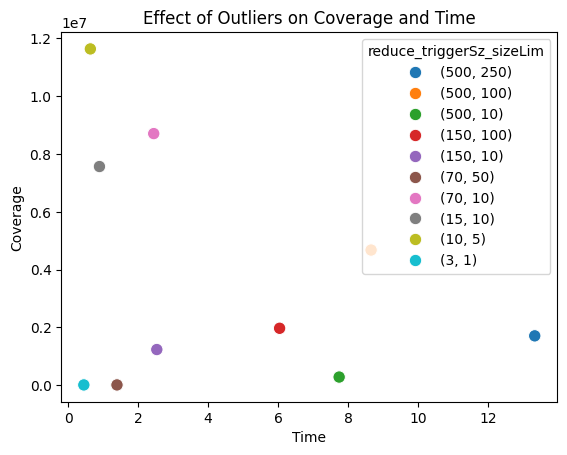

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(
    data=df,
    x='sumtest_time_mean',
    y='result_coverage_mean',
    hue='reduce_triggerSz_sizeLim',
    # style='n_outliers',  # you can add number of outliers
    s=80
)
plt.title("Effect of Outliers on Coverage and Time")
plt.xlabel("Time")
plt.ylabel("Coverage")
plt.show()